In [1]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns 
pio.renderers.default = 'notebook' # force plotly to render inside the notebook

NYC People in Homless shelters + Evictions
1. How are eviction trends related to homelessness in New York City?
2. Do increases in evictions correspond with increases in the number of people staying in NYC homeless shelters?
3. Which boroughs experience the highest levels of eviction and homelessness.
4. Eviction by Borough chart(graph)
5. Shelter by Borough chart (graph)
6. Homeless population over time chart (graph)
7. Compare eviction vs population(graph)

In [2]:
df_evictions = pd.read_csv("Evictions_20260715.csv")
df_shelter_people = pd.read_csv("DHS_Daily_Report_20260715.csv")

In [3]:
df_evictions

,Court Index Number,Docket Number,Eviction Address,Eviction Apartment Number,Executed Date,Marshal First Name,Marshal Last Name,Residential/Commercial,BOROUGH,Eviction Postcode,Ejectment,Eviction/Legal Possession,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA
0,325688/23,26140,2565 MARION AVENUE APT 2C,2C,09/17/2025,Robert,Renzulli,Residential,BRONX,10458,Not an Ejectment,Possession,40.862931,-73.892217,7.0,15.0,39901.0,2016602.0,2.032860e+09,Bedford Park-Fordham North
1,57364/16*,166775,2776 JEROME AVENUE,1E,03/16/2017,Alfred,Locascio,Residential,BRONX,10468,Not an Ejectment,Possession,40.869722,-73.895327,7.0,14.0,40303.0,2017499.0,2.033180e+09,Van Cortlandt Village
2,330886/22A,123564,1563 METROPOLITAN AVENUE,4A,08/13/2025,Darlene,Barone,Residential,BRONX,10462,Not an Ejectment,Possession,40.839696,-73.858059,9.0,18.0,21001.0,2096772.0,2.039448e+09,Parkchester
3,318146/24B,144754,637 EAST 224TH STR EET,4F,09/11/2025,Justin,Grossman,Residential,BRONX,10466,Not an Ejectment,Possession,40.887742,-73.862843,12.0,12.0,394.0,2121925.0,2.048260e+09,Williamsbridge-Olinville
4,B304354/25,139836,445 GERARD AVENUE,W818,01/21/2026,Darlene,Barone,Residential,BRONX,10451,Not an Ejectment,Possession,40.817398,-73.929872,1.0,8.0,63.0,2001095.0,2.023510e+09,West Concourse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130236,63313/18,61548,432 MILFORD STREET,2,06/04/2018,Howard,Schain,Residential,BROOKLYN,11208,Not an Ejectment,Possession,40.668334,-73.875262,5.0,42.0,1118.0,3393717.0,3.044560e+09,East New York
130237,76186/16A,65622,162 WEST 141ST ST,1,03/08/2018,Justin,Grossman,Residential,MANHATTAN,10030,Not an Ejectment,Possession,40.818617,-73.939809,10.0,9.0,230.0,1060077.0,1.020090e+09,Central Harlem North-Polo Grounds
130238,304096/23,16376,730 ROCKAWAY AVENUE APT 5A,5A,10/25/2024,Robert,Renzulli,Residential,BROOKLYN,11212,Not an Ejectment,Possession,40.661951,-73.908776,16.0,42.0,916.0,3397844.0,3.035890e+09,Brownsville
130239,310140/23,6969,507 EAST 161 STREET,13D,01/30/2024,David,Smith,Residential,BRONX,10451,Not an Ejectment,Possession,40.823066,-73.910004,3.0,17.0,141.0,2116648.0,2.023660e+09,Morrisania-Melrose


DATA WRANGLING OF EVICTIONS

In [4]:
df_evictions.isnull().sum()

Court Index Number               0
Docket Number                    0
Eviction Address                 0
Eviction Apartment Number    18849
Executed Date                    0
Marshal First Name               0
Marshal Last Name                0
Residential/Commercial           0
BOROUGH                          0
Eviction Postcode                0
Ejectment                      437
Eviction/Legal Possession        0
Latitude                     11582
Longitude                    11582
Community Board              11582
Council District             11582
Census Tract                 11582
BIN                          12052
BBL                          12052
NTA                          11582
dtype: int64

In [5]:
#changing date from obj to datetype
df_evictions['Executed Date'] = pd.to_datetime(df_evictions['Executed Date'], format='%m/%d/%Y')

In [6]:
#exctrating month and year to see evictions based on year and month 
df_evictions['Year'] = (df_evictions['Executed Date'].dt.year)
df_evictions['Month'] = (df_evictions['Executed Date'].dt.month)

In [7]:
#to make joining easier 
df_evictions['Month_Year'] = (df_evictions['Executed Date'].dt.to_period('M'))

In [8]:
df_evictions.dtypes

Court Index Number                      str
Docket Number                         int64
Eviction Address                        str
Eviction Apartment Number               str
Executed Date                datetime64[us]
Marshal First Name                      str
Marshal Last Name                       str
Residential/Commercial                  str
BOROUGH                                 str
Eviction Postcode                     int64
Ejectment                               str
Eviction/Legal Possession               str
Latitude                            float64
Longitude                           float64
Community Board                     float64
Council District                    float64
Census Tract                        float64
BIN                                 float64
BBL                                 float64
NTA                                     str
Year                                  int32
Month                                 int32
Month_Year                      

In [ ]:
df_shelter_people

DATA WRANGLING OF SHELTER POPULATION 

In [9]:
df_shelter_people.dtypes

Date of Census                                               str
Total Adults in Shelter                                    int64
Total Children in Shelter                                  int64
Total Individuals in Shelter                               int64
Single Adult Men in Shelter                                int64
Single Adult Women in Shelter                              int64
Total Single Adults in Shelter                             int64
Families with Children in Shelter                          int64
Adults in Families with Children in Shelter                int64
Children in Families with Children in Shelter              int64
Total Individuals in Families with Children in Shelter     int64
Adult Families in Shelter                                  int64
Individuals in Adult Families in Shelter                   int64
dtype: object

In [10]:
#changing date from obj to datetype
df_shelter_people['Date of Census'] = pd.to_datetime(df_shelter_people['Date of Census'], format='%m/%d/%Y')

In [11]:
df_shelter_people.isnull().sum()

Date of Census                                             0
Total Adults in Shelter                                    0
Total Children in Shelter                                  0
Total Individuals in Shelter                               0
Single Adult Men in Shelter                                0
Single Adult Women in Shelter                              0
Total Single Adults in Shelter                             0
Families with Children in Shelter                          0
Adults in Families with Children in Shelter                0
Children in Families with Children in Shelter              0
Total Individuals in Families with Children in Shelter     0
Adult Families in Shelter                                  0
Individuals in Adult Families in Shelter                   0
dtype: int64

In [12]:
df_shelter_people['Year'] = (df_shelter_people['Date of Census'].dt.year)
df_shelter_people['Month'] = (df_shelter_people['Date of Census'].dt.month)

In [13]:
df_shelter_people['Month_Year'] = (df_shelter_people['Date of Census'].dt.to_period('M'))

In [14]:
print(df_shelter_people["Month_Year"].min())
print(df_shelter_people["Month_Year"].max())

2021-03
2026-07


In [ ]:
print(df_evictions["Month_Year"].min())
print(df_evictions["Month_Year"].max())

Summarizing Each Data Set by Month Year THrough
Aggergated 

In [15]:

evictions_monthly = (
    df_evictions.groupby("Month_Year").size().reset_index(name="Evictions"))

In [16]:
shelter_monthly = (
    df_shelter_people.groupby("Month_Year")["Total Individuals in Shelter"].mean().reset_index(name="Average Shelter Population"))

In [17]:
evictions_monthly.head()

,Month_Year,Evictions
0,2017-01,2237
1,2017-02,1695
2,2017-03,2040
3,2017-04,1860
4,2017-05,2080


In [18]:
shelter_monthly.head()

,Month_Year,Average Shelter Population
0,2021-03,51399.806452
1,2021-04,50021.666667
2,2021-05,48677.903226
3,2021-06,47669.366667
4,2021-07,45395.645161


In [23]:
#merge inner to keep the months consistent 
df= pd.merge(
shelter_monthly,evictions_monthly, on="Month_Year", how="inner")

/tmp/ipykernel_4473/2195825981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


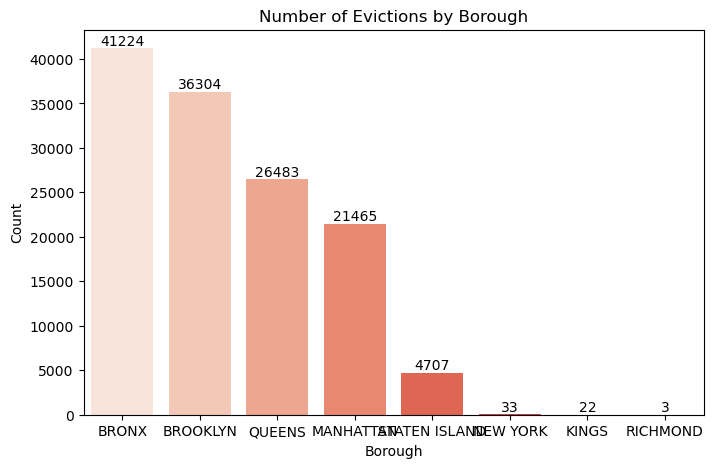

In [28]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_evictions,
    x="BOROUGH",
    order=df_evictions["BOROUGH"].value_counts().index,
    palette="Reds"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Evictions by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")

plt.show()

In [29]:
print(sorted(df_evictions["BOROUGH"].unique()))

['BRONX', 'BROOKLYN', 'KINGS', 'MANHATTAN', 'NEW YORK', 'QUEENS', 'RICHMOND', 'STATEN ISLAND']


In [33]:
df_evictions["BOROUGH"] = df_evictions["BOROUGH"].replace({"KINGS": "BROOKLYN", "NEW YORK": "MANHATTAN","RICHMOND": "STATEN ISLAND"})

In [51]:
df_evictions['BOROUGH'].unique()

KeyError: 'BOROUGH'

/tmp/ipykernel_4473/4055519547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


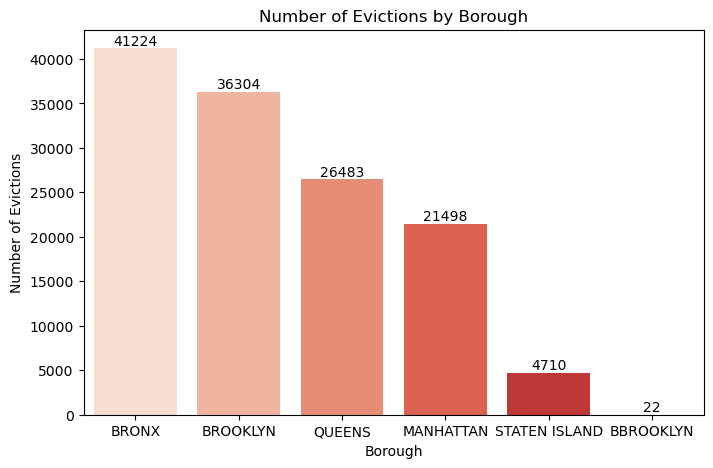

In [34]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_evictions,
    x="BOROUGH",
    order=df_evictions["BOROUGH"].value_counts().index,
    palette="Reds"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Evictions by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Evictions")

plt.show()

In [49]:
df_evictions["BOROUGH"] = df_evictions["BOROUGH"].str.replace("BBROOKLYN","BROOKLYN")

KeyError: 'BOROUGH'